# I. Preparation

Libraries needed to run the analysis:

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
from sklearn.preprocessing import MinMaxScaler
import random
from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import matplotlib.offsetbox as offsetbox # for text box with position control
import pickle
import seaborn as sns
import copy
import sys

Functions to

1. Read data from txt files
2. Build a feature matrix of 1's and 0's that can be used to train the neural network

In [2]:
def dissectSeq(sq):
    aaList = []
    counter = 0
    for a in sq:
        aaList.append(str(counter)+a)
        counter+=1
    return ':'.join(aaList)

def containsMutations(genotype):
    return genotype.split(':')

def makeBinary(unique_mutations, genotype):
    genotypeList = containsMutations(genotype)
    indexList = []
    
    for i in range(len(genotypeList)):
        indexList.append(unique_mutations.index(genotypeList[i]))
    
    line = np.zeros((1,len(unique_mutations)))
    line[:,indexList] = 1.
    
    return line

def read_data_all_positions(input_file):
    
    data = pd.read_table(input_file,
                         dtype = {"aa_seq" : object})
    data.columns = ['fitness', 'aa_seq']
    
    genotypeList = [dissectSeq(sq) for sq in data.aa_seq]
    mutation_list = pd.Series(genotypeList)
    
    unique_mutations = set(':'.join(mutation_list).split(':'))
    unique_mutations = sorted(list(unique_mutations))
    
    if '' in unique_mutations:
        unique_mutations.remove('')

    nn_genotypes_values = np.zeros((len(data), len(unique_mutations)))
    nn_fitness_values = data.fitness.values
    aa_seq = data.aa_seq
    
    for i in range(len(mutation_list)):
        if mutation_list[i] != '':
            nn_genotypes_values[i] = makeBinary(unique_mutations, mutation_list[i])[0]
    
    return nn_genotypes_values, nn_fitness_values, unique_mutations, aa_seq, mutation_list

Read the data into Python:

In [3]:
# file name
dataset_filename = "data/S7.txt"

# read data
feature_matrix, observed_fitness, unique_mutations, aa_sequences, sequence_ids = read_data_all_positions(dataset_filename)

Prepare data to build the neural network -

1. Scale all fitness values between 0 and 1
2. Split data into training and testing sets

In [4]:
# re-scaling the fitness values (for some reason the neural network can only predict things between 0 and 1??)
print("rescaling the fitness values between 0 and 1...")
min_max_scaler = MinMaxScaler()
fitness_values_scaled = min_max_scaler.fit_transform(observed_fitness.reshape(-1,1))

# split data into training and validation sets
print("splitting data into training and testing sets (95-05 split)...")
random.seed(1)
tf.random.set_seed(123)
x_train, x_valid, y_train, y_valid = train_test_split(feature_matrix,
                                                      fitness_values_scaled,
                                                      test_size = 0.05)

rescaling the fitness values between 0 and 1...
splitting data into training and testing sets (95-05 split)...


# II. Neural Network

In [5]:
# swish activation function
def swish(x, beta = 1):
    return (x * keras.backend.sigmoid(beta * x))

keras.utils.get_custom_objects().update({'swish': keras.layers.Activation(swish)})

In [6]:
number_additive_traits = 1


#######################################################################
## BUILD NEURAL NETWORK WITH FUNCTIONAL API & SPLITTING INPUT IN TWO ##
#######################################################################
random.seed(123)
tf.random.set_seed(456)

input_layer = keras.layers.Input(shape = x_train.shape[1:],
                                 name = "inputlayer")

# additive trait layers
additive_trait_layer = keras.layers.Dense(number_additive_traits,
                                          input_dim=feature_matrix.shape[1],
                                          kernel_initializer='glorot_normal',
                                          activation="linear",
                                          name = "additivetrait",
                                          kernel_regularizer = keras.regularizers.l2(0.05)
                                         )(input_layer)

# sigmoidal layers
swish_layer_1 = keras.layers.Dense(20,
                                   activation="swish",
                                   name = "swishlayer1")(additive_trait_layer)
swish_layer_2 = keras.layers.Dense(10,
                                   activation="swish",
                                   name = "swishlayer2")(swish_layer_1)
swish_layer_3 = keras.layers.Dense(5,
                                   activation="swish",
                                   name = "swishlayer3")(swish_layer_2)

# output layer
output_layer = keras.layers.Dense(1,
                                  activation = "linear",
                                  name = "outputlayer",
                                  kernel_initializer='glorot_normal')(swish_layer_3)

# create keras model defining input and output layers
model = keras.Model(inputs = [input_layer], outputs = [output_layer])


# optimiser algorithm
opt = keras.optimizers.Adam(lr = 0.001, beta_1=0.9,beta_2=0.999)

# no need for this if I'm using L2 regularisation
# use early stopping to avoid over fitting
#early_stopping_monitor=keras.callbacks.EarlyStopping(patience=50)

# compile the model
model.compile(optimizer=opt,
              loss='mean_absolute_error')

# fit the model
history = model.fit(x_train,
                    y_train,
                    validation_data=(x_valid,y_valid),
                    epochs=2500,
                    batch_size=128,
                    shuffle=True,
                    #callbacks=[early_stopping_monitor],
                    verbose=0)

In [7]:
model.summary()

Model: "model"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
inputlayer (InputLayer)      [(None, 46)]              0         
_________________________________________________________________
additivetrait (Dense)        (None, 1)                 47        
_________________________________________________________________
swishlayer1 (Dense)          (None, 20)                40        
_________________________________________________________________
swishlayer2 (Dense)          (None, 10)                210       
_________________________________________________________________
swishlayer3 (Dense)          (None, 5)                 55        
_________________________________________________________________
outputlayer (Dense)          (None, 1)                 6         
Total params: 358
Trainable params: 358
Non-trainable params: 0
_______________________________________________________________

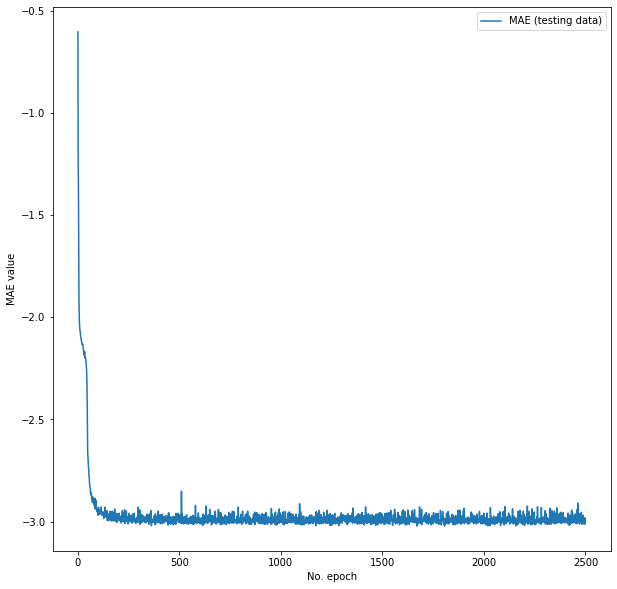

In [8]:
my_figure = plt.figure()
my_figure.set_size_inches(10, 10)

plt.plot(np.log(history.history['loss']), label='MAE (testing data)')
#plt.plot(np.log(history.history['val_loss']), label='MAE (validation data)')
plt.ylabel('MAE value')
plt.xlabel('No. epoch')
plt.legend()
plt.show()

In [9]:
# Save the entire model as a SavedModel.
!mkdir -p whole_model
model.save('whole_model/my_model') 

Instructions for updating:
If using Keras pass *_constraint arguments to layers.
INFO:tensorflow:Assets written to: whole_model/my_model/assets


In [10]:
model_predictions = model.predict(feature_matrix)

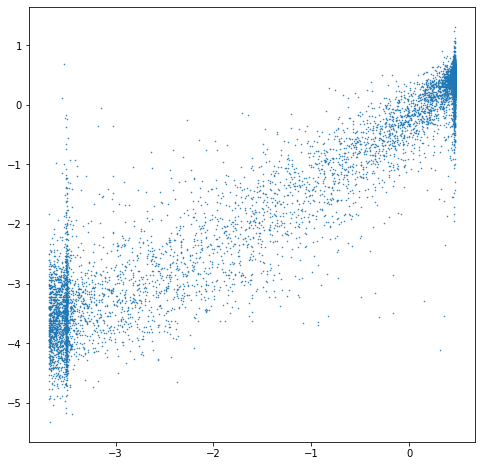

In [11]:
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

fig = plt.figure(figsize=(8,8))


## First additive trait ##
ax = fig.add_subplot(111)

ax.plot(min_max_scaler.inverse_transform(model_predictions),
        min_max_scaler.inverse_transform(fitness_values_scaled),
        "o",
        ms = 0.51)
#ax.plot([-6,2],[-6,2])


# Additive Traits

In [12]:
# little function that gives me the layer index if I know its name
def getLayerIndexByName(model, layername):
    for idx, layer in enumerate(model.layers):
        if layer.name == layername:
            return idx

# idx for additive trait 1 layer
layer_idx = getLayerIndexByName(model = model,
                                layername = "additivetrait")

# calculate reconstructed additive trait 1
additive_traits_model = keras.Model(inputs = model.input,
                                     outputs = model.layers[layer_idx].output)

reconstructed_additive_trait_df = pd.DataFrame(additive_traits_model.predict(feature_matrix))

reconstructed_additive_trait_df.columns = [ "trait " + str(i) for i in range(len(reconstructed_additive_trait_df.columns))]

In [13]:
reconstructed_additive_trait_df

,trait 0
0,0.116824
1,-0.011851
2,0.091194
3,0.096787
4,0.006693
...,...
9150,-0.171653
9151,-0.136154
9152,-0.138300
9153,-0.117546


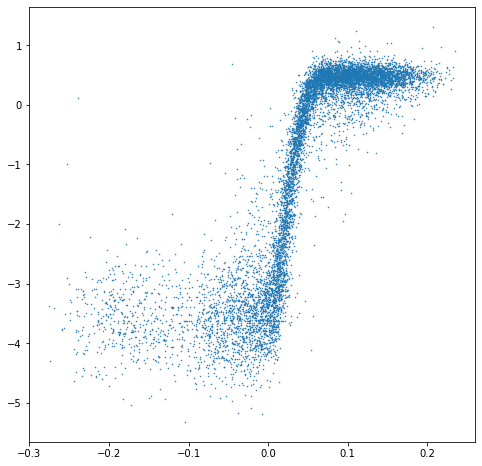

In [14]:
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

fig = plt.figure(figsize=(8,8))


## First additive trait ##
ax = fig.add_subplot(111)

ax.plot(reconstructed_additive_trait_df["trait 0"],
        min_max_scaler.inverse_transform(fitness_values_scaled),
        "o",
        ms = 0.51)

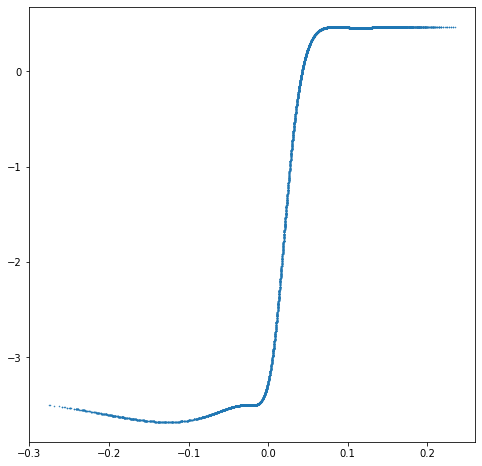

In [15]:
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

fig = plt.figure(figsize=(8,8))


## First additive trait ##
ax = fig.add_subplot(111)

ax.plot(reconstructed_additive_trait_df["trait 0"],
        min_max_scaler.inverse_transform(model_predictions),
        "o",
        ms = 0.51)

In [16]:
dataframe_to_export = pd.DataFrame({"seq" : aa_sequences,
                                    "observed_fitness" : observed_fitness,
                                    "predicted_fitness" : min_max_scaler.inverse_transform(model_predictions).flatten(),
                                    "additive_trait" : reconstructed_additive_trait_df["trait 0"]})

In [17]:
dataframe_to_export.to_csv("001_1D_Predictions.txt",
                           sep = "\t",
                           index = False)